In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from grid2op.PlotGrid import PlotMatplot
from lightsim2grid import LightSimBackend

In [2]:
import os
import grid2op as gp

In [4]:
gp.list_available_remote_env()

['l2rpn_2019',
 'l2rpn_case14_sandbox',
 'l2rpn_neurips_2020_track1_large',
 'l2rpn_neurips_2020_track1_small',
 'l2rpn_neurips_2020_track2_large',
 'l2rpn_neurips_2020_track2_small',
 'l2rpn_wcci_2020',
 'rte_case14_realistic',
 'rte_case14_redisp',
 'wcci_test']

In [6]:
from grid2op.Agent import DoNothingAgent, TopologyGreedy, GreedyAgent, RandomAgent

In [3]:
# Use LightSim2Grid backend
backend = LightSimBackend()

In [8]:
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
env.reset()

/Users/dai/.pyenv/versions/3.8.5/envs/grid/lib/python3.8/site-packages/grid2op/MakeEnv/Make.py:282: UserWarning: It is the first time you use the environment "l2rpn_neurips_2020_track1_small".
We will attempt to download this environment from remote
  warnings.warn(_MAKE_FIRST_TIME_WARN.format(dataset_name))
l2rpn_neurips_2020_track1_small.tar.bz2: 0.00B [00:00, ?B/s]

downloading the training data, this may take a while.


l2rpn_neurips_2020_track1_small.tar.bz2: 896MB [01:27, 10.2MB/s]                               


Extract the tar archive in "/Users/dai/data_grid2op"
You may now use the environment "l2rpn_neurips_2020_track1_small" with the available data by invoking:
	env = grid2op.make("l2rpn_neurips_2020_track1_small")


In [5]:
plot_helper = PlotMatplot(env.observation_space)

NameError: name 'env' is not defined

In [10]:
env.chronics_handler.subpaths[:10]

array(['/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_000',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_001',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_002',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_003',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_004',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_005',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_006',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_007',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_008',
       '/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_009'],
      dtype='<U87')

In [11]:
len(env.chronics_handler.subpaths)

576

In [194]:
env.chronics_handler.get_id()

'/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_000'

In [196]:
env.chronics_handler.max_timestep()

8062

In [204]:
env.chronics_handler.data

In [205]:
env.chronics_handler.data.prod_p

array([[  0. ,  25.3,   0. , ..., 399. ,   0. ,  27.7],
       [  0. ,  24.6,   0. , ..., 399. ,   0. ,  27.6],
       [  0. ,  24.6,   0. , ..., 399. ,   0. ,  27.6],
       ...,
       [  0. ,  26.6,   0. , ..., 399. ,   0. ,  36. ],
       [  0. ,  26.5,   0. , ..., 399. ,   0. ,  37.2],
       [  0. ,  26.9,   0. , ..., 399. ,   0. ,  36.6]], dtype=float32)

In [206]:
env.chronics_handler.data.prod_p.shape

(8063, 22)

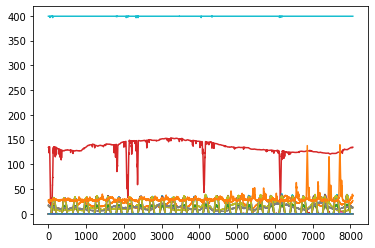

In [208]:
plot(env.chronics_handler.data.prod_p)

In [209]:
print(env.chronics_handler.data.load_p.shape)
env.chronics_handler.data.load_p

(8063, 37)


array([[ 12.  ,  -1.14,   5.12, ...,  24.  , -24.87, -26.94],
       [ 11.8 ,  -0.29,   5.8 , ...,  23.25, -24.12, -27.29],
       [ 11.3 ,  -0.63,   5.33, ...,  24.73, -23.35, -29.16],
       ...,
       [ 13.5 ,  -7.2 ,   0.43, ...,   4.12, -21.92, -19.69],
       [ 14.  ,  -7.79,   0.11, ...,   4.69, -21.7 , -19.72],
       [ 13.5 ,  -6.59,   1.02, ...,   3.27, -21.35, -19.68]],
      dtype=float32)

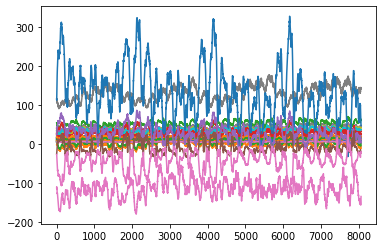

In [210]:
plot(env.chronics_handler.data.load_p)

In [215]:
env.chronics_handler.data.maintenance.shape

(8063, 59)

In [222]:
handler = env.chronics_handler
n = len(handler.subpaths)
env.set_id(0)
for i in range(n):
    env.reset()
    print(handler.get_name(), handler.max_timestep(), handler.data.current_datetime)

Scenario_april_000 8062 2012-04-01 00:05:00
Scenario_april_001 8062 2012-04-01 00:05:00
Scenario_april_002 8062 2012-04-01 00:05:00
Scenario_april_003 8062 2012-04-01 00:05:00
Scenario_april_004 8062 2012-04-01 00:05:00
Scenario_april_005 8062 2012-04-01 00:05:00
Scenario_april_006 8062 2012-04-01 00:05:00
Scenario_april_007 8062 2012-04-01 00:05:00
Scenario_april_008 8062 2012-04-01 00:05:00
Scenario_april_009 8062 2012-04-01 00:05:00
Scenario_april_010 8062 2012-04-01 00:05:00
Scenario_april_011 8062 2012-04-01 00:05:00
Scenario_april_012 8062 2012-04-01 00:05:00
Scenario_april_013 8062 2012-04-01 00:05:00
Scenario_april_014 8062 2012-04-01 00:05:00
Scenario_april_015 8062 2012-04-01 00:05:00
Scenario_april_016 8062 2012-04-01 00:05:00
Scenario_april_017 8062 2012-04-01 00:05:00
Scenario_april_018 8062 2012-04-01 00:05:00
Scenario_april_019 8062 2012-04-01 00:05:00
Scenario_april_020 8062 2012-04-01 00:05:00
Scenario_april_021 8062 2012-04-01 00:05:00
Scenario_april_022 8062 2012-04-

Scenario_february_036 8062 2012-02-01 00:05:00
Scenario_february_037 8062 2012-02-01 00:05:00
Scenario_february_038 8062 2012-02-01 00:05:00
Scenario_february_039 8062 2012-02-01 00:05:00
Scenario_february_040 8062 2012-02-01 00:05:00
Scenario_february_041 8062 2012-02-01 00:05:00
Scenario_february_042 8062 2012-02-01 00:05:00
Scenario_february_043 8062 2012-02-01 00:05:00
Scenario_february_044 8062 2012-02-01 00:05:00
Scenario_february_045 8062 2012-02-01 00:05:00
Scenario_february_046 8062 2012-02-01 00:05:00
Scenario_february_047 8062 2012-02-01 00:05:00
Scenario_january_000 8062 2012-01-01 00:05:00
Scenario_january_001 8062 2012-01-01 00:05:00
Scenario_january_002 8062 2012-01-01 00:05:00
Scenario_january_003 8062 2012-01-01 00:05:00
Scenario_january_004 8062 2012-01-01 00:05:00
Scenario_january_005 8062 2012-01-01 00:05:00
Scenario_january_006 8062 2012-01-01 00:05:00
Scenario_january_007 8062 2012-01-01 00:05:00
Scenario_january_008 8062 2012-01-01 00:05:00
Scenario_january_009 8

Scenario_march_030 8062 2012-03-01 00:05:00
Scenario_march_031 8062 2012-03-01 00:05:00
Scenario_march_032 8062 2012-03-01 00:05:00
Scenario_march_033 8062 2012-03-01 00:05:00
Scenario_march_034 8062 2012-03-01 00:05:00
Scenario_march_035 8062 2012-03-01 00:05:00
Scenario_march_036 8062 2012-03-01 00:05:00
Scenario_march_037 8062 2012-03-01 00:05:00
Scenario_march_038 8062 2012-03-01 00:05:00
Scenario_march_039 8062 2012-03-01 00:05:00
Scenario_march_040 8062 2012-03-01 00:05:00
Scenario_march_041 8062 2012-03-01 00:05:00
Scenario_march_042 8062 2012-03-01 00:05:00
Scenario_march_043 8062 2012-03-01 00:05:00
Scenario_march_044 8062 2012-03-01 00:05:00
Scenario_march_045 8062 2012-03-01 00:05:00
Scenario_march_046 8062 2012-03-01 00:05:00
Scenario_march_047 8062 2012-03-01 00:05:00
Scenario_may_000 8062 2012-05-01 00:05:00
Scenario_may_001 8062 2012-05-01 00:05:00
Scenario_may_002 8062 2012-05-01 00:05:00
Scenario_may_003 8062 2012-05-01 00:05:00
Scenario_may_004 8062 2012-05-01 00:05:0

Scenario_september_020 8062 2012-09-01 00:05:00
Scenario_september_021 8062 2012-09-01 00:05:00
Scenario_september_022 8062 2012-09-01 00:05:00
Scenario_september_023 8062 2012-09-01 00:05:00
Scenario_september_024 8062 2012-09-01 00:05:00
Scenario_september_025 8062 2012-09-01 00:05:00
Scenario_september_026 8062 2012-09-01 00:05:00
Scenario_september_027 8062 2012-09-01 00:05:00
Scenario_september_028 8062 2012-09-01 00:05:00
Scenario_september_029 8062 2012-09-01 00:05:00
Scenario_september_030 8062 2012-09-01 00:05:00
Scenario_september_031 8062 2012-09-01 00:05:00
Scenario_september_032 8062 2012-09-01 00:05:00
Scenario_september_033 8062 2012-09-01 00:05:00
Scenario_september_034 8062 2012-09-01 00:05:00
Scenario_september_035 8062 2012-09-01 00:05:00
Scenario_september_036 8062 2012-09-01 00:05:00
Scenario_september_037 8062 2012-09-01 00:05:00
Scenario_september_038 8062 2012-09-01 00:05:00
Scenario_september_039 8062 2012-09-01 00:05:00
Scenario_september_040 8062 2012-09-01 0

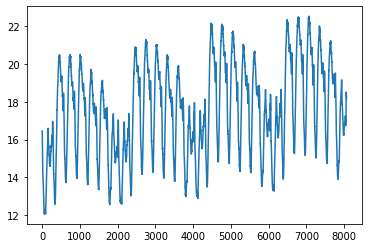

In [263]:
# Mean load
env.set_id(0)
mean = zeros(8063)
for i in range(48):
    env.reset()
    mean += handler.data.load_p[:, 10] / 48
plot(mean)

(0.0, 2.0575734071784257)

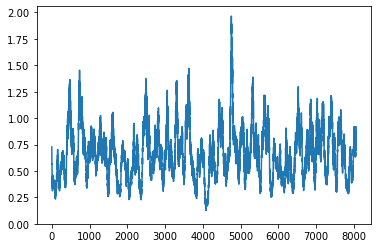

In [269]:
# Variance load
env.set_id(0)
var = zeros(8063)
for i in range(48):
    env.reset()
    var += square(handler.data.load_p[:, 10] - mean) / 48
plot(var)
ylim(0)

In [275]:
env.grid_objects_types

array([[ 0, -1, -1,  2, -1],
       [ 0,  0, -1, -1, -1],
       [ 0,  1, -1, -1, -1],
       [ 1, -1, -1,  3, -1],
       [ 1, -1, -1,  4, -1],
       [ 1, -1, -1, 12, -1],
       [ 1, -1,  0, -1, -1],
       [ 1,  2, -1, -1, -1],
       [ 1,  3, -1, -1, -1],
       [ 2, -1, -1,  0, -1],
       [ 2, -1, -1,  1, -1],
       [ 2,  4, -1, -1, -1],
       [ 3, -1, -1, -1,  0],
       [ 3, -1, -1, -1,  3],
       [ 3,  5, -1, -1, -1],
       [ 4, -1, -1, -1,  1],
       [ 4, -1, -1, -1,  2],
       [ 4, -1, -1, -1,  4],
       [ 4, -1, -1,  5, -1],
       [ 4, -1, -1,  6, -1],
       [ 4, -1, -1, -1, 55],
       [ 5, -1, -1, 46, -1],
       [ 5, -1, -1, 55, -1],
       [ 5,  6, -1, -1, -1],
       [ 6, -1, -1, -1,  5],
       [ 6, -1, -1,  7, -1],
       [ 6,  7, -1, -1, -1],
       [ 7, -1, -1, -1,  6],
       [ 7, -1, -1, -1,  7],
       [ 7, -1, -1,  8, -1],
       [ 7, -1, -1,  9, -1],
       [ 7, -1,  1, -1, -1],
       [ 7,  8, -1, -1, -1],
       [ 8, -1, -1, -1,  8],
       [ 8, -1

In [248]:
env.gen_type

array(['thermal', 'wind', 'thermal', 'hydro', 'thermal', 'wind', 'solar',
       'solar', 'wind', 'solar', 'thermal', 'solar', 'solar', 'thermal',
       'solar', 'solar', 'thermal', 'wind', 'solar', 'nuclear', 'thermal',
       'thermal'], dtype='<U10')

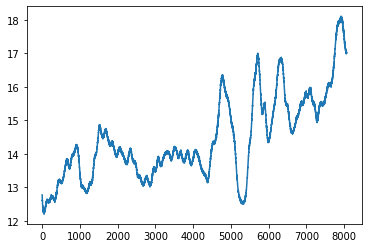

In [270]:
# Mean prod wind
env.set_id(0)
mean = zeros(8063)
for i in range(48):
    env.reset()
    mean += handler.data.prod_p[:, 1] / 48
plot(mean)

(0.0, 123.87942133900924)

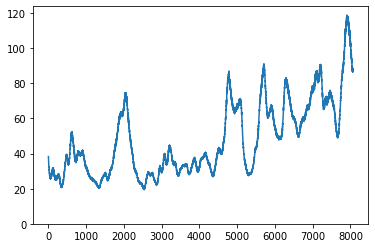

In [271]:
# Variance prod wind
env.set_id(0)
var = zeros(8063)
for i in range(48):
    env.reset()
    var += square(handler.data.prod_p[:, 1] - mean) / 48
plot(var)
ylim(0)

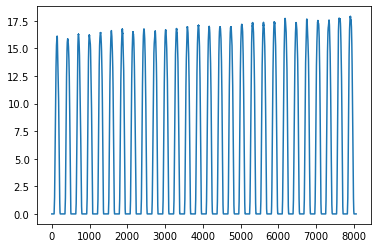

In [272]:
# Mean prod solar
env.set_id(0)
mean = zeros(8063)
for i in range(48):
    env.reset()
    mean += handler.data.prod_p[:, 6] / 48
plot(mean)

(0.0, 2.87272977768904)

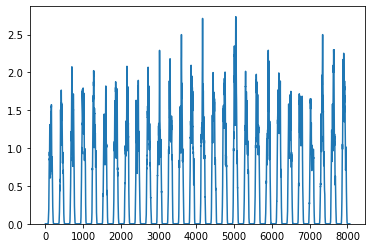

In [273]:
# Variance prod solar
env.set_id(0)
var = zeros(8063)
for i in range(48):
    env.reset()
    var += square(handler.data.prod_p[:, 6] - mean) / 48
plot(var)
ylim(0)

In [14]:
# %%timeit
# random.seed(2)
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
# env = gp.make('rte_case14_redisp', backend=backend)
# env = gp.make('rte_case14_redisp')
env.seed(1)
obs = env.reset()
null_agent = DoNothingAgent(env.action_space)
tg_agent = TopologyGreedy(env.action_space)
rand_agent = RandomAgent(env.action_space)
# rand_agent.seed(1)
# plot_helper.plot_obs(obs)
print(env.chronics_handler.get_name())
done = False
acc_rew, duration = 0, 0
while not done:
    ac = null_agent.act(obs, 0)
#     ac = tg_agent.act(obs, rew, done)
#     ac = rand_agent.act(obs, rew, done)
    obs, rew, done, info = env.step(ac)
    acc_rew += rew
    duration += 1
print(acc_rew, duration)
# Takes 9.86 s ± 4.76 ms per loop (7 runs) on pandapower backend
# Takes 2.08 s ± 83.6 ms per loop (7 runs) on lightsim2grid backend

Scenario_april_001
323931.7568359375 338


In [179]:
# PandaPower backend
# Scenario_april_001
# 323931.7568359375 338

# LightSim2Grid backend
# Scenario_april_001
# 323931.7568359375 338

(220844.39575195312, 182)

In [166]:
env.backend._grid

This pandapower network includes the following parameter tables:
   - bus (72 elements)
   - load (37 elements)
   - gen (22 elements)
   - shunt (6 elements)
   - line (55 elements)
   - trafo (4 elements)
   - bus_geodata (36 elements)
 and the following results tables:
   - res_bus (72 elements)
   - res_line (55 elements)
   - res_trafo (4 elements)
   - res_load (37 elements)
   - res_shunt (6 elements)
   - res_gen (22 elements)

In [13]:
env.sub_info

array([ 3,  6,  3,  3,  6,  3,  3,  6,  3,  7,  3,  3,  4,  5,  4,  3, 17,
        3,  4,  3,  3,  8,  5, 10,  3,  3,  9,  5,  5,  7,  2,  3,  5,  7,
        3,  7], dtype=int32)

In [228]:
sum(2**env.sub_info)

133908

In [229]:
len(conv.all_actions) - _

255

In [231]:
len(env.gen_type)

22

In [225]:
env.dim_topo

177

(array([17.,  3.,  8.,  4.,  2.,  1.,  0.,  0.,  0.,  1.]),
 array([ 2. ,  3.5,  5. ,  6.5,  8. ,  9.5, 11. , 12.5, 14. , 15.5, 17. ]),
 <BarContainer object of 10 artists>)

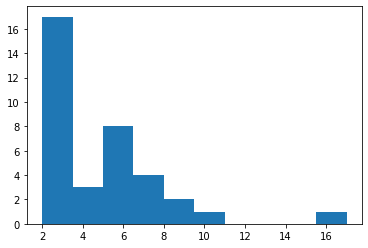

In [232]:
hist(env.sub_info)

(array([12., 13.,  6., 10.,  6.,  4.,  4.,  1.,  1.,  2.]),
 array([ 60.9    , 129.73   , 198.56   , 267.39   , 336.22   , 405.05002,
        473.88   , 542.71   , 611.54004, 680.37   , 749.2    ],
       dtype=float32),
 <BarContainer object of 10 artists>)

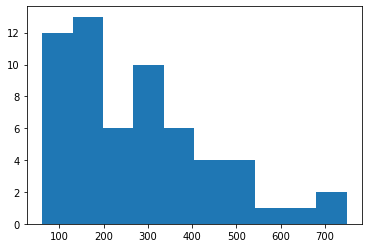

In [163]:
hist(env._thermal_limit_a)

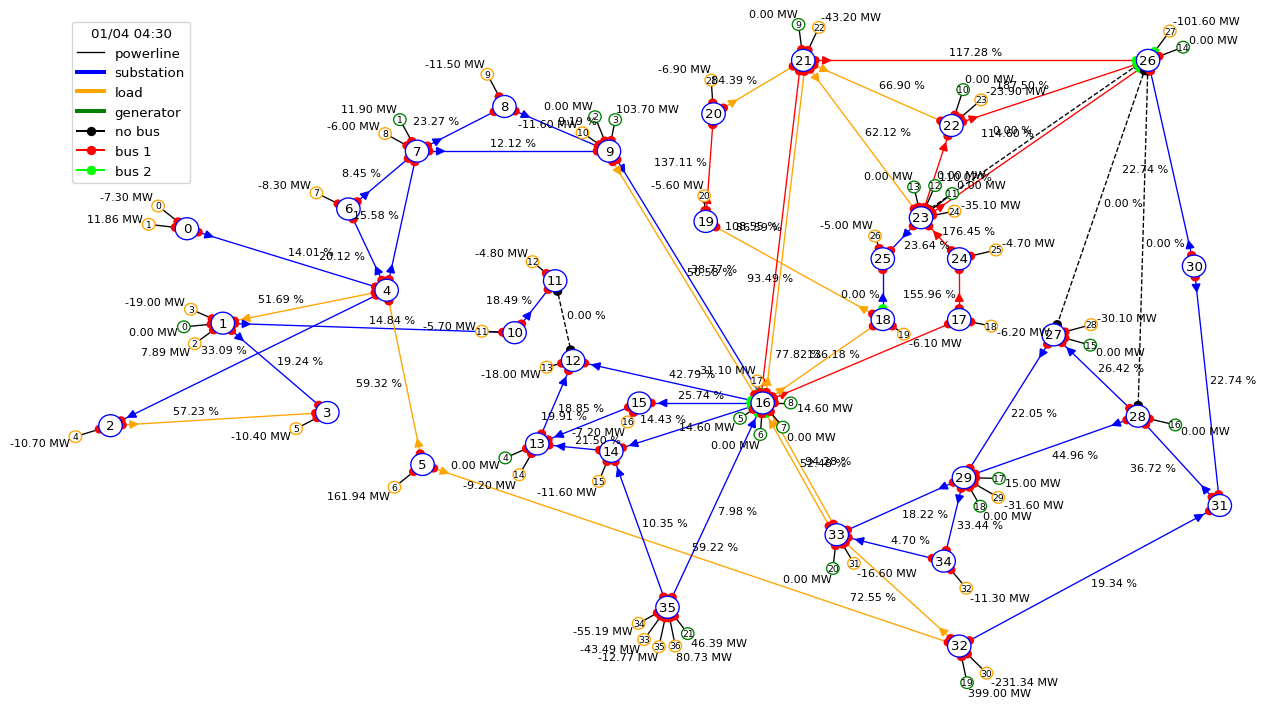

In [144]:
fig = plot_helper.plot_obs(obs)

In [22]:
info

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False,  True, False,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True,  True, False,  True, False, False, False, False, False,
        False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, 

In [24]:
# Null agent total reward
acc_rew

331917.9280395508

In [29]:
acc_rew

320567.1735839844

In [31]:
env.chronics_handler.get_name()

'Scenario_april_003'

In [52]:
obs.prod_p.sum() - obs.load_p.sum()

14.229858

In [53]:
obs.prod_q.sum() - obs.load_q.sum()

-285.92548

In [66]:
sim_obs, sim_rew, sim_done, sim_info = obs.simulate(env.action_space({}))

In [69]:
sim_info

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': None,
 'opponent_attack_sub': None,
 'opponent_attack_duration': 0,
 'exception': [],
 'rewards': {}}

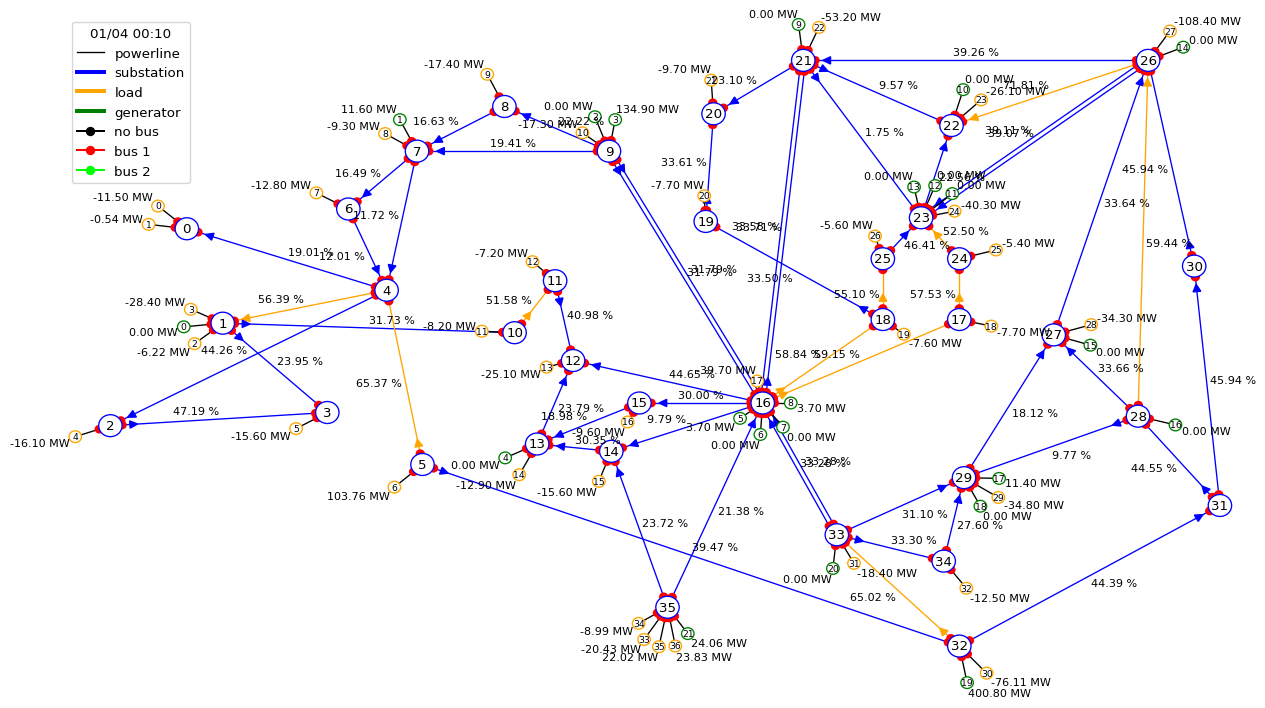

In [74]:
fig = plot_helper.plot_obs(sim_obs)

In [76]:
sim_obs.simulate(env.action_space({}))

NoForecastAvailable: Grid2OpException NoForecastAvailable "No forecasts are available for this instance of BaseObservation (no action_space and no simulated environment are set)."

In [83]:
from grid2op.Converter import IdToAct

In [100]:
conv = IdToAct(env.action_space)

In [104]:
conv.convert_act(1)

IndexError: list index out of range

In [95]:
_92.as_dict()

{}

In [96]:
env.reset()

In [103]:
conv.sample()

0

In [105]:
env.action_space.n

494

In [106]:
env.action_space.sample()

In [109]:
conv.init_converter()

In [111]:
len(conv.all_actions)

134163

In [112]:
conv.all_actions[100]

In [116]:
conv.all_actions[1500].to_vect()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 2.,
       1., 2., 1., 1., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [117]:
sqrt(134000)

366.0601043544625

In [1]:
import grid2op as gp
from lightsim2grid import LightSimBackend
import l2rpn_baselines
l2rpn_baselines.__file__
backend = LightSimBackend()

In [9]:
import importlib
importlib.reload(l2rpn_baselines.PandapowerOPFAgent)

<module 'l2rpn_baselines.PandapowerOPFAgent' from '/Users/dai/dev/lab/grid/l2rpn-baselines/l2rpn_baselines/PandapowerOPFAgent/__init__.py'>

In [3]:
# Compare OPF baseline with the null agent
from l2rpn_baselines.PandapowerOPFAgent import PandapowerOPFAgent

In [15]:
env.init_grid_path

'/Users/dai/data_grid2op/l2rpn_neurips_2020_track1_small/grid.json'

In [7]:
# %%timeit
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
env.seed(1)
obs = env.reset()
opf_agent = PandapowerOPFAgent(env.action_space, env.init_grid_path, opf_type='powermodels')
print(env.chronics_handler.get_name())
done = False
acc_rew, duration = 0, 0
while not done:
#     ac = null_agent.act(obs, rew)
    ac = opf_agent.act(obs, 0)
    obs, rew, done, info = env.step(ac)
    acc_rew += rew
    duration += 1
    if duration > 10:
        break
print(acc_rew, duration)
# Takes 9.86 s ± 4.76 ms per loop (7 runs) on pandapower backend
# Takes 2.08 s ± 83.6 ms per loop (7 runs) on lightsim2grid backend

Scenario_april_001


FileNotFoundError: [Errno 2] No such file or directory: 'julia'

In [9]:
ac.gen_max_ramp_down

array([ 1.4,  0. ,  1.4, 10.4,  1.4,  0. ,  0. ,  0. ,  0. ,  0. ,  2.8,
        0. ,  0. ,  2.8,  0. ,  0. ,  4.3,  0. ,  0. ,  2.8,  8.5,  9.9],
      dtype=float32)

In [10]:
env.gen_type

array(['thermal', 'wind', 'thermal', 'hydro', 'thermal', 'wind', 'solar',
       'solar', 'wind', 'solar', 'thermal', 'solar', 'solar', 'thermal',
       'solar', 'solar', 'thermal', 'wind', 'solar', 'nuclear', 'thermal',
       'thermal'], dtype='<U10')

In [14]:
print(ac)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


In [ ]:
# Null agent
# 9.52 s ± 1.12 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
# 10439.464782714844 11
# OPF agent
# 9925.696594238281 11
# took >100s per step

In [18]:
env.

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.], dtype=float32)